## Load Raw Fashion-MNIST

In [2]:
from torchvision.datasets import FashionMNIST
trainset = FashionMNIST(root='data', 
                        train=True, 
                        download=True)

img, label = trainset[0]
print(type(img), label)

<class 'PIL.Image.Image'> 9


In [3]:
type(img)

PIL.Image.Image

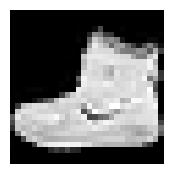

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(img, cmap='gray')  
plt.axis('off')  # Hide axis
plt.show()

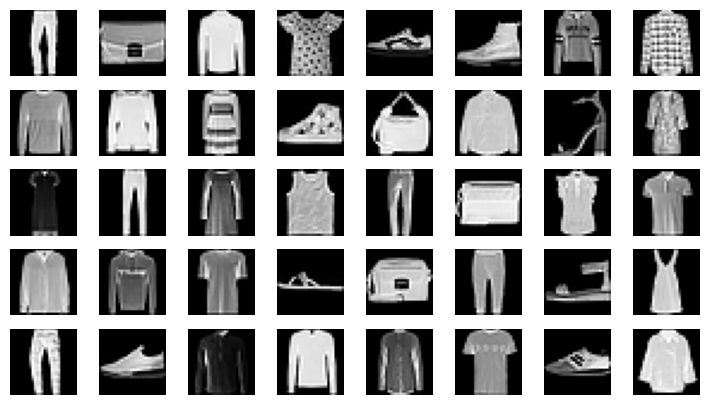

In [5]:
import matplotlib.pyplot as plt 
import numpy as np 

# Tạo indices cho 64 phần tử ngẫu nhiên
indices = np.random.randint(60000, size=40)

fig =plt.figure(figsize=(9, 5))
columns = 8
rows = 5
for i in range(1, columns*rows +1):
    img, label = trainset[indices[i-1]]
    fig.add_subplot(rows, columns, i)
    plt.axis('off')
    plt.imshow(img, cmap='gray', vmin=0, vmax=255)

## Convert to Tensor

In [ ]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms

transform = transforms.Compose([transforms.ToTensor()])
trainset = FashionMNIST(root='data', train=True, 
                        download=True, transform=transform)

img, label = trainset[0]
print(type(img), label)
print(img.shape)

<class 'torch.Tensor'> 9
torch.Size([1, 28, 28])


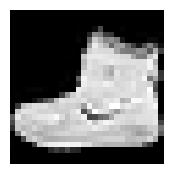

In [ ]:
import matplotlib.pyplot as plt

img, _ = trainset[0]
np_img = img.numpy().reshape(28, 28)

plt.figure(figsize=(2,2))
plt.imshow(np_img, cmap='gray')
plt.axis('off')  
plt.show()

## Mini-batch

In [2]:
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader
from torchvision import transforms

transform = transforms.Compose([transforms.ToTensor()])
trainset = FashionMNIST(root='data', 
                        train=True, 
                        download=True, 
                        transform=transform)

trainloader = DataLoader(trainset, 
                         batch_size=1024, 
                         num_workers=6, 
                         shuffle=True)
print(len(trainloader))
print(type(trainloader))

100%|██████████| 26.4M/26.4M [00:07<00:00, 3.39MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 164kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.30MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 5.33MB/s]


59
<class 'torch.utils.data.dataloader.DataLoader'>


In [3]:
for d in trainloader:
    images, labels = d
    print(images.shape)
    print(labels.shape)
    break

torch.Size([1024, 1, 28, 28])
torch.Size([1024])


In [4]:
# batch_size=1024
for i, (inputs, labels) in enumerate(trainloader, 0):
    print(f'Batch index {i} -- {inputs.shape} -- {labels.shape}')

Batch index 0 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 1 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 2 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 3 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 4 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 5 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 6 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 7 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 8 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 9 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 10 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 11 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 12 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 13 -- torch.Size([1024, 1, 28, 28]) -- torch.Size([1024])
Batch index 14 -- torch.Size([

Besides converting PIL object to Tensors, <code>transforms.ToTensor()</code> also normalize the pixels in the images

In [ ]:
for img, _ in trainloader:
    break

print("Max:", img.max(), "\tMin:", img.min()) # Values of pixels from (0, 255) -> (0, 1) after transformation

Max: tensor(1.) 	Min: tensor(0.)
